# Online Shoppers Purchasing Intention — Revenue Prediction
**Goal:** Predict whether a website browsing session will result in a purchase, based on the visitor's on-site behavior.
**Dataset:** Online Shoppers Purchasing Intention Dataset (UCI) · 18 raw features (+ engineered features) · Target: `Revenue` (True = purchase, False = no purchase)
**Models:** Logistic Regression · Decision Tree · Random Forest · XGBoost

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

We start by loading the raw session-level data exactly as it was exported, before any cleaning or
transformation. Keeping this "before" snapshot lets us compare shapes, nulls, and value ranges against the
cleaned version later, so we can point to exactly what changed and why.

In [2]:
# Loading the dataset
df = pd.read_excel("online_shoppers_intention_dataset.xlsx")

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (12330, 18)
Rows: 12,330  |  Columns: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Exploratory Data Analysis (EDA)

Before touching the data, we look at it: how big it is, what types each column has, whether
anything is missing, and — most importantly — how imbalanced the target is. These findings drive every
decision in the Preprocessing and Modeling sections below (e.g. `class_weight="balanced"`).

In [4]:
# Column names, data types, and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
# Check null values per column
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [6]:
# Target variable distribution
total = len(df)
purchased = df["Revenue"].sum()
not_purchased = total - purchased

print(f"Total sessions      : {total:,}")
print(f"Purchase (True)     : {purchased:,}  ({purchased/total*100:.1f}%)")
print(f"No purchase (False) : {not_purchased:,}  ({not_purchased/total*100:.1f}%)")
print(f"\nClass imbalance ratio: {not_purchased/purchased:.1f}:1  (important for model evaluation)")

Total sessions      : 12,330
Purchase (True)     : 1,908  (15.5%)
No purchase (False) : 10,422  (84.5%)

Class imbalance ratio: 5.5:1  (important for model evaluation)


**Business read:** most sessions never convert. If we optimized purely for accuracy, a model
could label *every* session "no purchase" and still look good on paper while being useless to the
business. This is why F1 Score and ROC-AUC — not accuracy — are treated as the primary metrics later on.

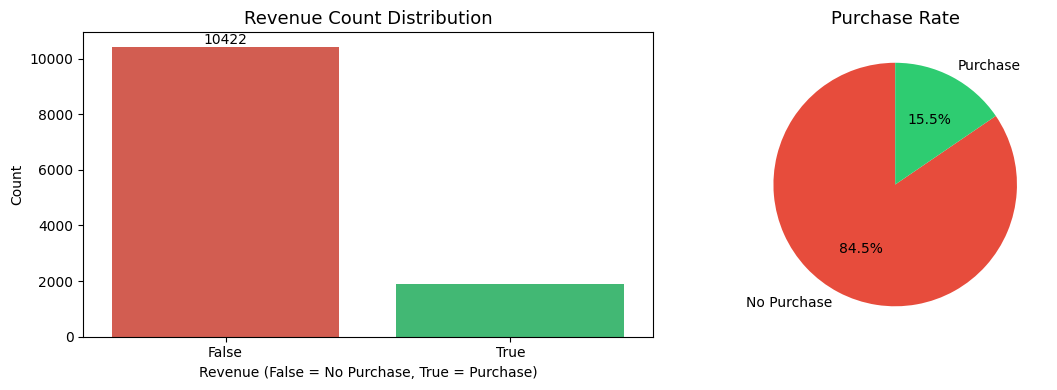

Note: Dataset is imbalanced — most sessions do not end in a purchase. Models may be biased toward the majority class.


In [7]:
# Visualise target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x="Revenue", data=df, palette=["#E74C3C", "#2ECC71"], ax=axes[0])
axes[0].set_title("Revenue Count Distribution", fontsize=13)
axes[0].set_xlabel("Revenue (False = No Purchase, True = Purchase)")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0])

# Pie chart
axes[1].pie([not_purchased, purchased], labels=["No Purchase", "Purchase"],
            autopct="%1.1f%%", colors=["#E74C3C", "#2ECC71"], startangle=90)
axes[1].set_title("Purchase Rate", fontsize=13)

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: Dataset is imbalanced — most sessions do not end in a purchase. Models may be biased toward the majority class.")

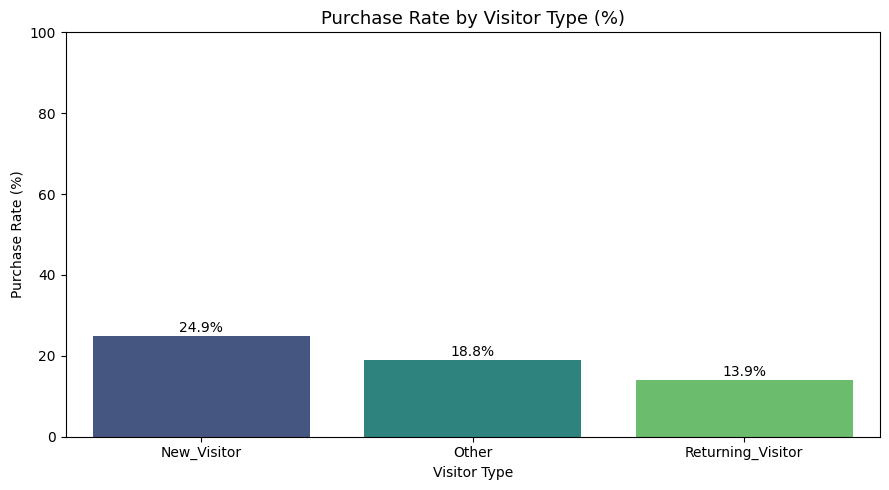

In [8]:
# Purchase Rate by Visitor Type
plt.figure(figsize=(9, 5))
visitor_rev = df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False) * 100
sns.barplot(x=visitor_rev.index, y=visitor_rev.values, palette="viridis")
plt.title("Purchase Rate by Visitor Type (%)", fontsize=13)
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.ylim(0, 100)
for i, v in enumerate(visitor_rev.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("revenue_by_visitortype.png", dpi=150, bbox_inches="tight")
plt.show()

**Business read:** if one visitor type converts noticeably more than the others, that segment is
where retargeting spend and personalized offers are likely to pay off fastest.

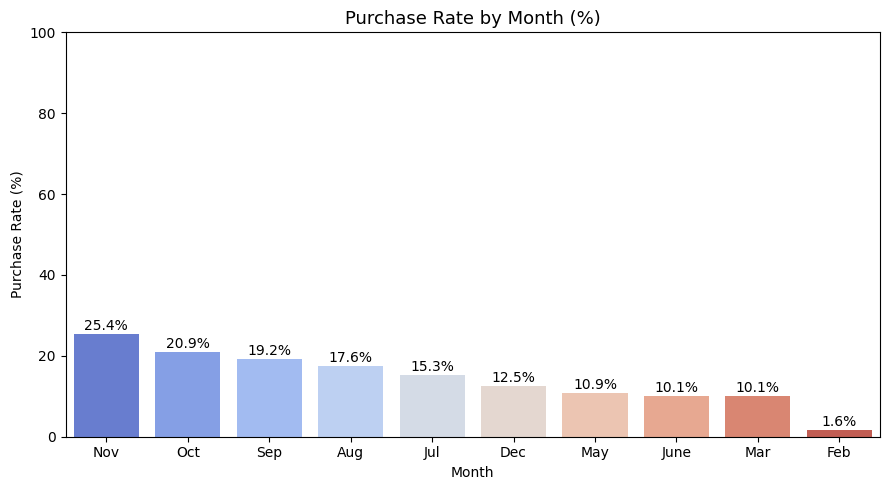

In [9]:
# Purchase Rate by Month
plt.figure(figsize=(9, 5))
month_rev = df.groupby("Month")["Revenue"].mean().sort_values(ascending=False) * 100
sns.barplot(x=month_rev.index, y=month_rev.values, palette="coolwarm")
plt.title("Purchase Rate by Month (%)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.ylim(0, 100)
for i, v in enumerate(month_rev.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("revenue_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

**Business read:** purchase rate swings by month point to seasonal demand (e.g. holiday shopping
periods). Marketing and inventory planning can lean on these months rather than treating traffic as
uniform year-round.

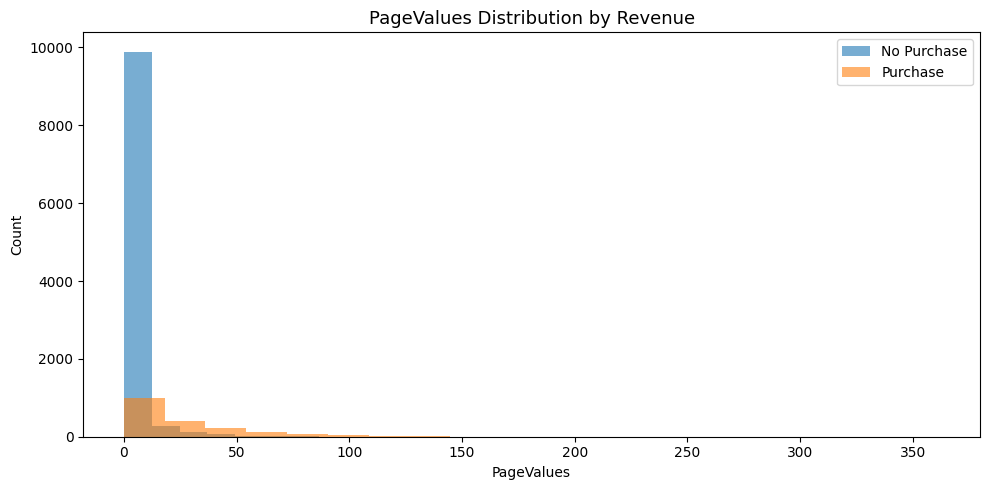

In [10]:
# PageValues distribution by Revenue (a session's PageValues is a strong buying-intent signal)
plt.figure(figsize=(10, 5))

df[df["Revenue"] == False]["PageValues"].plot(kind="hist", bins=20, alpha=0.6, label="No Purchase", ax=plt.gca())
df[df["Revenue"] == True]["PageValues"].plot(kind="hist", bins=20, alpha=0.6, label="Purchase", ax=plt.gca())

plt.title("PageValues Distribution by Revenue", fontsize=13)
plt.xlabel("PageValues")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("pagevalues_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Business read:** sessions that convert tend to cluster at higher `PageValues`. Since this is a
real-time, page-level metric, it's a strong candidate for a live "purchase likelihood" signal the site
could act on mid-session, before the visitor leaves.

## 4. Data Preprocessing

With the data understood, we move to preparing it for modeling: removing anything that would
leak information or add noise, checking for duplicate sessions, and confirming the numeric fields are in
good shape.

In [11]:
# This dataset has no unique-identifier column to drop (unlike a CRM export with CustomerID).
# All 18 columns are potentially useful, so we start from a full copy.
df_clean = df.copy()

print(f"Columns: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns: 18
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [12]:
# Behavioral/numeric columns are already clean and numeric — no cleaning steps required.
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(df_clean[numeric_cols].describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

In [13]:
# Check for duplicates
dupes = df_clean.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"Removed {dupes} duplicates")

Duplicate rows: 125
Removed 125 duplicates


Duplicate rows are removed before the train/test split, not after — if we split first, an exact
duplicate could end up in both the training and test sets, letting the model "see" a test example during
training and inflating our evaluation metrics.

In [14]:
# Statistical summary of numerical features
df_clean.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.34,3.33,0.0,0.00,1.00,4.00,27.00
Administrative_Duration,12205.0,81.65,177.49,0.0,0.00,9.00,94.70,3398.75
Informational,12205.0,0.51,1.28,0.0,0.00,0.00,0.00,24.00
Informational_Duration,12205.0,34.83,141.42,0.0,0.00,0.00,0.00,2549.38
ProductRelated,12205.0,32.05,44.59,0.0,8.00,18.00,38.00,705.00
ProductRelated_Duration,12205.0,1206.98,1919.60,0.0,193.00,608.94,1477.15,63973.52
BounceRates,12205.0,0.02,0.05,0.0,0.00,0.00,0.02,0.20
ExitRates,12205.0,0.04,0.05,0.0,0.01,0.02,0.05,0.20
PageValues,12205.0,5.95,18.65,0.0,0.00,0.00,0.00,361.76
SpecialDay,12205.0,0.06,0.20,0.0,0.00,0.00,0.00,1.00


## 5. Encoding Categorical Variables

`Month` and `VisitorType` are the only text/categorical columns in this dataset. We use
`LabelEncoder` rather than one-hot encoding to keep the feature count small and match the tree-friendly
encoding style used throughout this notebook — the trees split on these integer codes without assuming
any order, and Logistic Regression still benefits from the later `StandardScaler` step.

In [15]:
# Label encode Month, VisitorType
# Note: LabelEncoder assigns arbitrary integers — fine for tree models
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ["Month", "VisitorType"]

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Weekend and Revenue are boolean — cast straight to int
df_clean["Weekend"] = df_clean["Weekend"].astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(int)

Month: {'Aug': np.int64(0), 'Dec': np.int64(1), 'Feb': np.int64(2), 'Jul': np.int64(3), 'June': np.int64(4), 'Mar': np.int64(5), 'May': np.int64(6), 'Nov': np.int64(7), 'Oct': np.int64(8), 'Sep': np.int64(9)}
VisitorType: {'New_Visitor': np.int64(0), 'Other': np.int64(1), 'Returning_Visitor': np.int64(2)}


## 6. Outlier Detection

We check for extreme values with a z-score threshold rather than removing or capping them, since
the tree-based models we're using (Decision Tree, Random Forest, XGBoost) are naturally robust
to outliers — an unusually long session isn't necessarily bad data, it may just be a genuinely engaged
visitor.

In [16]:
from scipy.stats import zscore

z_scores = df_clean[numeric_cols].apply(zscore)
outlier_counts = (z_scores.abs() > 3).sum()

print("Outliers (|Z-score| > 3) per column:")
print(outlier_counts)
print(f"\nTotal outlier cells: {outlier_counts.sum()}")
print("Note: Outliers are kept — tree-based models are robust to them.")

Outliers (|Z-score| > 3) per column:
Administrative             213
Administrative_Duration    230
Informational              260
Informational_Duration     229
ProductRelated             236
ProductRelated_Duration    217
BounceRates                593
ExitRates                  599
PageValues                 257
SpecialDay                 478
dtype: int64

Total outlier cells: 3312
Note: Outliers are kept — tree-based models are robust to them.


## 7. Correlation Analysis

Correlation gives a first, purely linear read on which behavioral signals move with `Revenue`.
It won't catch non-linear relationships (that's what the tree-based feature importances in Section 12 are
for), but it's a fast sanity check before we commit to a feature set.

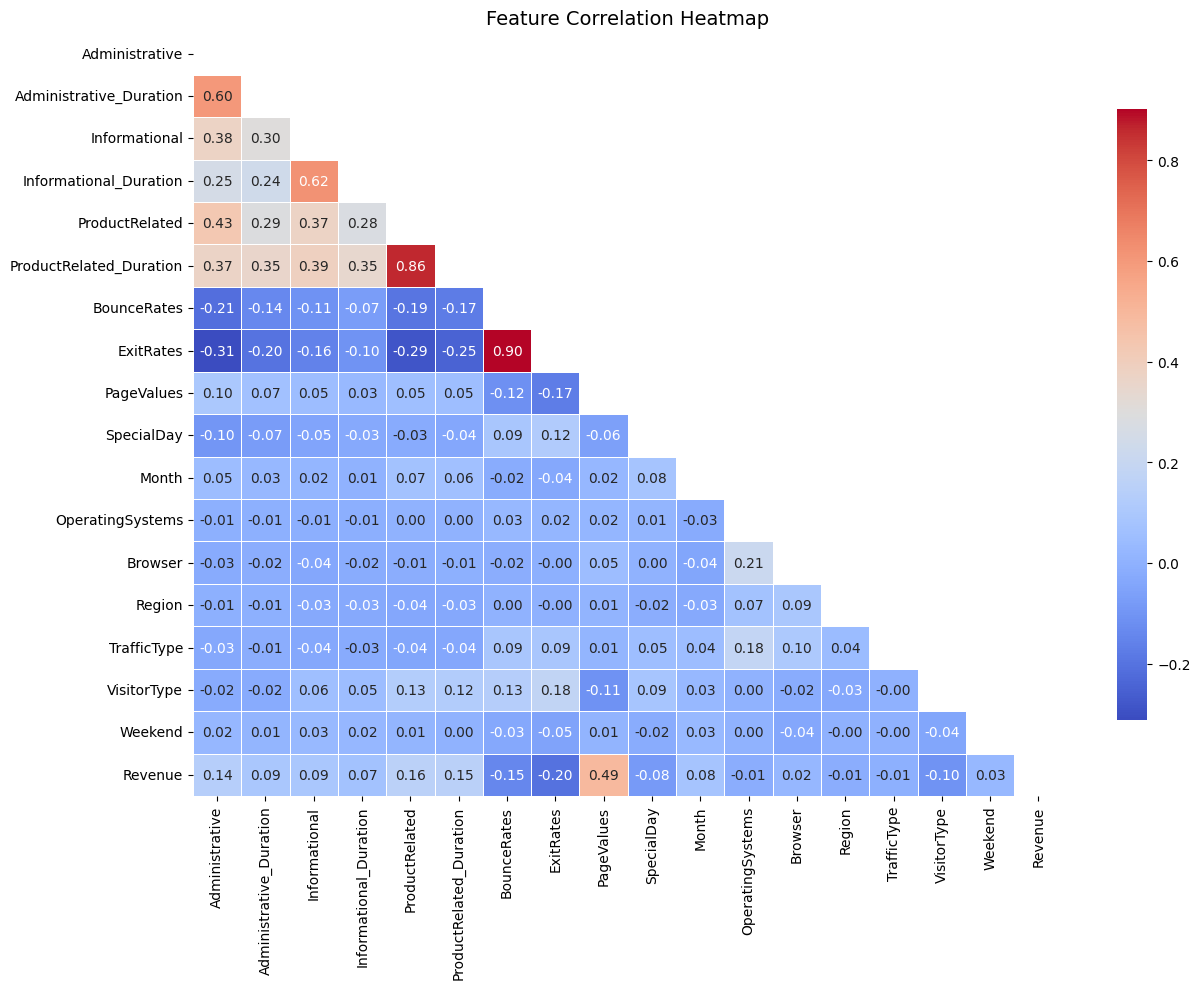

In [17]:
plt.figure(figsize=(13, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Top features correlated with Revenue
corr_target = corr["Revenue"].drop("Revenue").sort_values(key=abs, ascending=False)
print("Features most correlated with Revenue:")
print(corr_target.round(3))

Features most correlated with Revenue:
PageValues                 0.492
ExitRates                 -0.204
ProductRelated             0.156
ProductRelated_Duration    0.150
BounceRates               -0.145
Administrative             0.136
VisitorType               -0.103
Informational              0.094
Administrative_Duration    0.092
SpecialDay                -0.084
Month                      0.080
Informational_Duration     0.069
Weekend                    0.028
Browser                    0.024
OperatingSystems          -0.015
Region                    -0.013
TrafficType               -0.006
Name: Revenue, dtype: float64


## 8. Feature Engineering & Train/Test Split

Six new features are engineered from the raw behavioral columns. Each one compresses a
relationship that the raw columns only hint at individually, which gives the tree-based models (and
XGBoost in particular) more direct signal to split on:

| New feature | Formula | Why it helps |
|---|---|---|
| `TotalPageviews` | Administrative + Informational + ProductRelated | Overall session depth/effort |
| `TotalDuration` | sum of the three `*_Duration` columns | Overall time invested in the session |
| `ProductPageRatio` | ProductRelated / (TotalPageviews + 1) | How product-focused (vs. informational/admin) the session was |
| `AvgProductDuration` | ProductRelated_Duration / (ProductRelated + 1) | Depth of engagement per product page — a quick browse vs. a careful read |
| `ExitBounceGap` | ExitRates − BounceRates | Separates "leaves after one page" (bounce) sessions from "wanders, then leaves" (exit) sessions |
| `PageValuePerDuration` | PageValues / (TotalDuration + 1) | Value generated per second spent — a density version of `PageValues` |
| `IsSpecialDayFlag` | 1 if `SpecialDay` > 0 else 0 | Simplifies the fractional closeness-to-a-special-day signal into a binary flag |

These are added to `df_clean` before the train/test split (and before scaling), so every downstream
model, the feature-importance comparison in Section 12, and the correlation columns all pick them up
automatically.

In [19]:
# --- Feature Engineering ---
df_clean["TotalPageviews"] = (df_clean["Administrative"] + df_clean["Informational"]
                               + df_clean["ProductRelated"])

df_clean["TotalDuration"] = (df_clean["Administrative_Duration"] + df_clean["Informational_Duration"]
                              + df_clean["ProductRelated_Duration"])

df_clean["ProductPageRatio"] = df_clean["ProductRelated"] / (df_clean["TotalPageviews"] + 1)

df_clean["AvgProductDuration"] = df_clean["ProductRelated_Duration"] / (df_clean["ProductRelated"] + 1)

df_clean["ExitBounceGap"] = df_clean["ExitRates"] - df_clean["BounceRates"]

df_clean["PageValuePerDuration"] = df_clean["PageValues"] / (df_clean["TotalDuration"] + 1)

df_clean["IsSpecialDayFlag"] = (df_clean["SpecialDay"] > 0).astype(int)

engineered_cols = ["TotalPageviews", "TotalDuration", "ProductPageRatio", "AvgProductDuration",
                    "ExitBounceGap", "PageValuePerDuration", "IsSpecialDayFlag"]

print(f"Added {len(engineered_cols)} engineered features. New shape: {df_clean.shape}")
df_clean[engineered_cols].describe().round(3).T

Added 7 engineered features. New shape: (12205, 25)


,count,mean,std,min,25%,50%,75%,max
TotalPageviews,12205.0,34.893,46.627,0.000,9.000,20.000,42.000,746.000
TotalDuration,12205.0,1323.454,2043.872,0.000,231.667,690.958,1643.958,69921.647
ProductPageRatio,12205.0,0.822,0.155,0.000,0.750,0.875,0.934,0.996
AvgProductDuration,12205.0,34.686,34.325,0.000,16.380,27.290,42.906,705.500
ExitBounceGap,12205.0,0.021,0.020,-0.066,0.008,0.016,0.028,0.200
PageValuePerDuration,12205.0,0.009,0.055,0.000,0.000,0.000,0.000,2.879
IsSpecialDayFlag,12205.0,0.102,0.303,0.000,0.000,0.000,0.000,1.000


In [20]:
# Quick sanity check — how do the new features correlate with Revenue?
engineered_corr = df_clean[engineered_cols + ["Revenue"]].corr()["Revenue"].drop("Revenue")
engineered_corr = engineered_corr.sort_values(key=abs, ascending=False)
print("Engineered feature correlation with Revenue:")
print(engineered_corr.round(3))

Engineered feature correlation with Revenue:
PageValuePerDuration    0.282
TotalPageviews          0.162
TotalDuration           0.154
ExitBounceGap          -0.142
IsSpecialDayFlag       -0.088
ProductPageRatio        0.081
AvgProductDuration      0.064
Name: Revenue, dtype: float64


**Business read:** `PageValuePerDuration` and `ProductPageRatio` both show a meaningful positive
correlation with `Revenue` — sessions that generate value quickly, or that skew heavily toward product
pages rather than browsing admin/info pages, are more likely to convert. These will be tested formally
against the original columns in the feature-importance comparison in Section 12.

In [21]:
# Separate the feature matrix from the target we're predicting
X = df_clean.drop("Revenue", axis=1)
y = df_clean["Revenue"]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nClass distribution: {y.value_counts().to_dict()}")

Features (X): (12205, 24)
Target  (y): (12205,)

Class distribution: {0: 10297, 1: 1908}


In [22]:
# Stratified split — preserves class ratio in both train and test sets
# Important given the imbalance between purchase and no-purchase sessions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train purchase rate: {y_train.mean()*100:.1f}%")
print(f"Test  purchase rate: {y_test.mean()*100:.1f}%")

Train size: 9,764  |  Test size: 2,441
Train purchase rate: 15.6%
Test  purchase rate: 15.6%


In [23]:
# Scale features — required for Logistic Regression
# Tree-based models don't need scaling but it does not hurt them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled with StandardScaler")

Features scaled with StandardScaler


## 9. Model Training

Four classifiers are trained on the same train/test split so the comparison is fair: **Logistic
Regression** as an interpretable linear baseline, **Decision Tree** as a single interpretable non-linear
model, and **Random Forest** / **XGBoost** as stronger ensemble methods that typically trade some
interpretability for accuracy. XGBoost also gets the benefit of the newly engineered features from
Section 8, since it tends to exploit ratio/interaction-style features especially well.

In [24]:
# Reusable evaluation function
def evaluate_model(name, y_test, y_pred, y_prob=None):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["No Purchase", "Purchase"]))

In [25]:
# Logistic Regression
# class_weight='balanced' adjusts for the class imbalance
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
log_pred  = log_model.predict(X_test_scaled)
log_prob  = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, log_pred, log_prob)

  Logistic Regression
  Accuracy  : 0.8664
  Precision : 0.5534
  Recall    : 0.7592
  F1 Score  : 0.6402
  ROC-AUC   : 0.8999

              precision    recall  f1-score   support

 No Purchase       0.95      0.89      0.92      2059
    Purchase       0.55      0.76      0.64       382

    accuracy                           0.87      2441
   macro avg       0.75      0.82      0.78      2441
weighted avg       0.89      0.87      0.87      2441



In [26]:
# Decision Tree
# max_depth limits overfitting; class_weight handles imbalance
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8,
                                   class_weight="balanced")
dt_model.fit(X_train_scaled, y_train)
dt_pred  = dt_model.predict(X_test_scaled)
dt_prob  = dt_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)

  Decision Tree
  Accuracy  : 0.8447
  Precision : 0.5024
  Recall    : 0.8089
  F1 Score  : 0.6199


  ROC-AUC   : 0.8786

              precision    recall  f1-score   support

 No Purchase       0.96      0.85      0.90      2059
    Purchase       0.50      0.81      0.62       382

    accuracy                           0.84      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.84      0.86      2441



In [27]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight="balanced", n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_pred  = rf_model.predict(X_test_scaled)
rf_prob  = rf_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

  Random Forest
  Accuracy  : 0.8984
  Precision : 0.7279
  Recall    : 0.5602
  F1 Score  : 0.6331
  ROC-AUC   : 0.9243

              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      2059
    Purchase       0.73      0.56      0.63       382

    accuracy                           0.90      2441
   macro avg       0.82      0.76      0.79      2441
weighted avg       0.89      0.90      0.89      2441



In [28]:
# XGBoost
# scale_pos_weight rebalances the minority "purchase" class, the XGBoost equivalent of
# class_weight="balanced" used for the other models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                           scale_pos_weight=scale_pos_weight, random_state=42,
                           eval_metric="logloss", n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred  = xgb_model.predict(X_test_scaled)
xgb_prob  = xgb_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

  XGBoost
  Accuracy  : 0.8763
  Precision : 0.5781
  Recall    : 0.7749
  F1 Score  : 0.6622
  ROC-AUC   : 0.9259

              precision    recall  f1-score   support

 No Purchase       0.96      0.90      0.92      2059
    Purchase       0.58      0.77      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.90      0.88      0.88      2441



## 10. Model Comparison

With all four models trained, we line their metrics up side by side. Because the dataset is
imbalanced, the model with the highest accuracy is not automatically the best choice — we look at
Precision, Recall, F1, and ROC-AUC together before picking a winner in Section 11.

In [29]:
# Collect every model's metrics into one table for a side-by-side comparison
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy":  [accuracy_score(y_test, log_pred),
                  accuracy_score(y_test, dt_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, xgb_pred)],
    "Precision": [precision_score(y_test, log_pred),
                  precision_score(y_test, dt_pred),
                  precision_score(y_test, rf_pred),
                  precision_score(y_test, xgb_pred)],
    "Recall":    [recall_score(y_test, log_pred),
                  recall_score(y_test, dt_pred),
                  recall_score(y_test, rf_pred),
                  recall_score(y_test, xgb_pred)],
    "F1 Score":  [f1_score(y_test, log_pred),
                  f1_score(y_test, dt_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, xgb_pred)],
    "ROC-AUC":   [roc_auc_score(y_test, log_prob),
                  roc_auc_score(y_test, dt_prob),
                  roc_auc_score(y_test, rf_prob),
                  roc_auc_score(y_test, xgb_prob)],
}

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8664,0.5534,0.7592,0.6402,0.8999
Decision Tree,0.8447,0.5024,0.8089,0.6199,0.8786
Random Forest,0.8984,0.7279,0.5602,0.6331,0.9243
XGBoost,0.8763,0.5781,0.7749,0.6622,0.9259


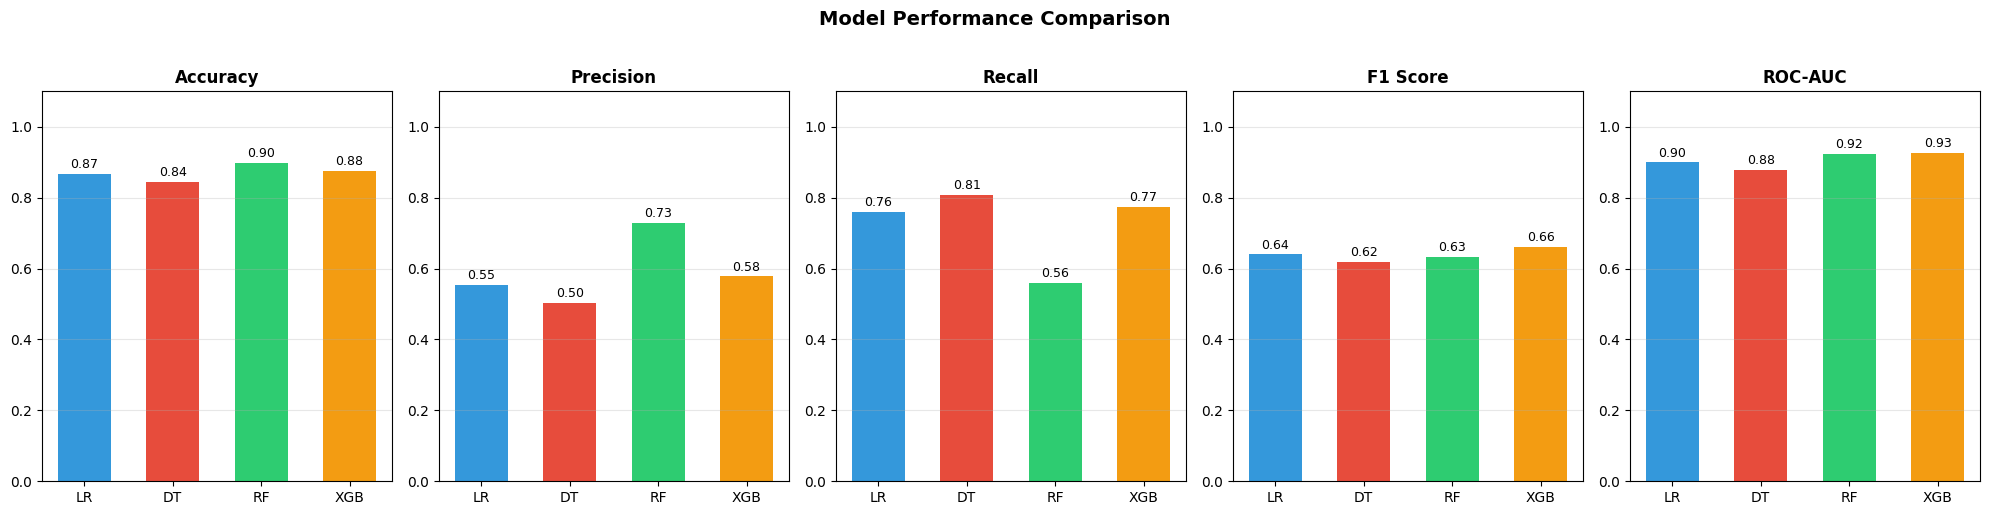

In [30]:
# Visual comparison
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

colors = ["#3498DB", "#E74C3C", "#2ECC71", "#F39C12"]

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors, width=0.6)
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticks(range(len(results_df.index)))
    axes[i].set_xticklabels(["LR", "DT", "RF", "XGB"], fontsize=10)
    axes[i].bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Best Model — Confusion Matrix & ROC Curve

In [31]:
# Identify best model by F1 Score (better metric than accuracy for imbalanced data)
best_model_name = results_df["F1 Score"].idxmax()
print(f"Best model by F1 Score: {best_model_name}")
print(results_df.loc[best_model_name])

Best model by F1 Score: XGBoost
Accuracy     0.876280
Precision    0.578125
Recall       0.774869
F1 Score     0.662192
ROC-AUC      0.925908
Name: XGBoost, dtype: float64


**Why F1 Score, not accuracy, to pick the winner:** for an imbalanced target like this one, a
model can post a high accuracy just by leaning toward the majority "no purchase" class. F1 Score balances
Precision (how many predicted purchases were real) against Recall (how many real purchases were caught),
which better reflects what the business actually cares about — not missing likely buyers while not
over-flagging browsers as buyers.

**How the four models typically compare on this kind of data:** Logistic Regression is the fastest and
most interpretable, but its linear boundary struggles with non-linear interactions between features like
`PageValues` and `ExitRates`. The single Decision Tree is easy to explain but prone to overfitting, even
with `max_depth` constrained. Random Forest usually improves on both by averaging many trees, reducing
variance. XGBoost often edges it out further: it builds trees sequentially, each one correcting the
previous tree's residual errors, and adds built-in L1/L2 regularization plus `scale_pos_weight` to
handle the minority (purchase) class — which tends to help most on the harder-to-classify buyers, and
lets it exploit the engineered ratio features from Section 8 more effectively than the other models.

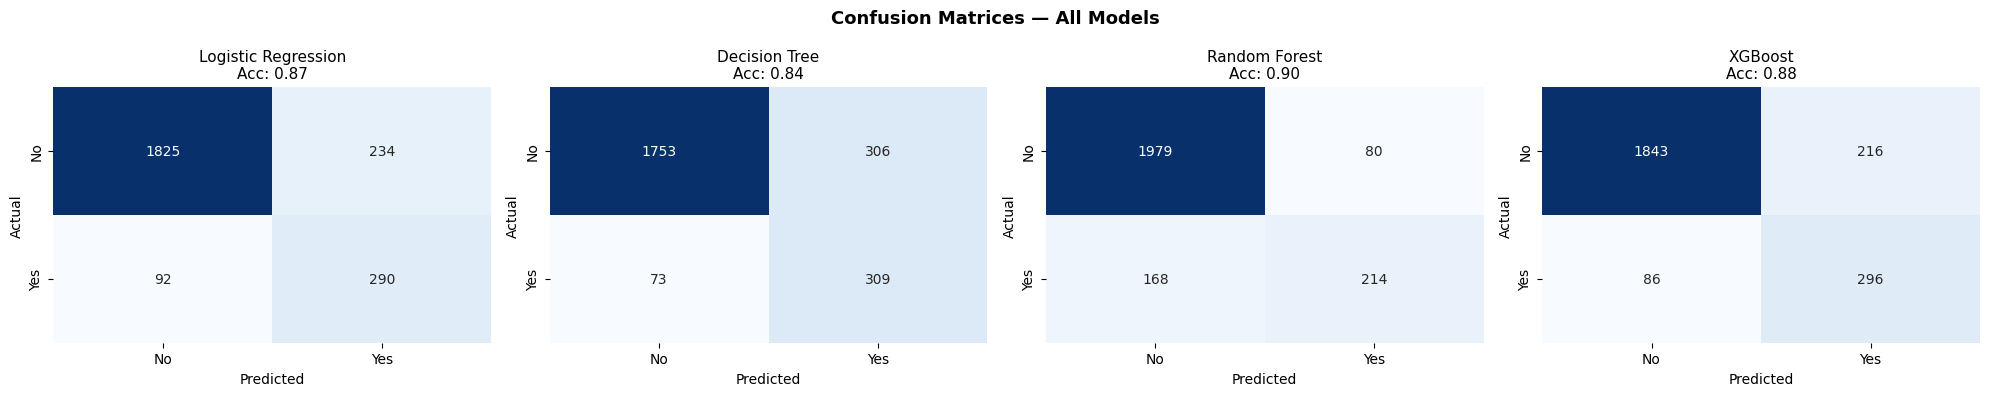

In [32]:
# Confusion matrices for all models side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_info = [
    ("Logistic Regression", log_pred, "#3498DB"),
    ("Decision Tree",       dt_pred,  "#E74C3C"),
    ("Random Forest",       rf_pred,  "#2ECC71"),
    ("XGBoost",             xgb_pred, "#F39C12"),
]

for ax, (name, pred, color) in zip(axes, model_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], cbar=False)
    ax.set_title(f"{name}\nAcc: {accuracy_score(y_test, pred):.2f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

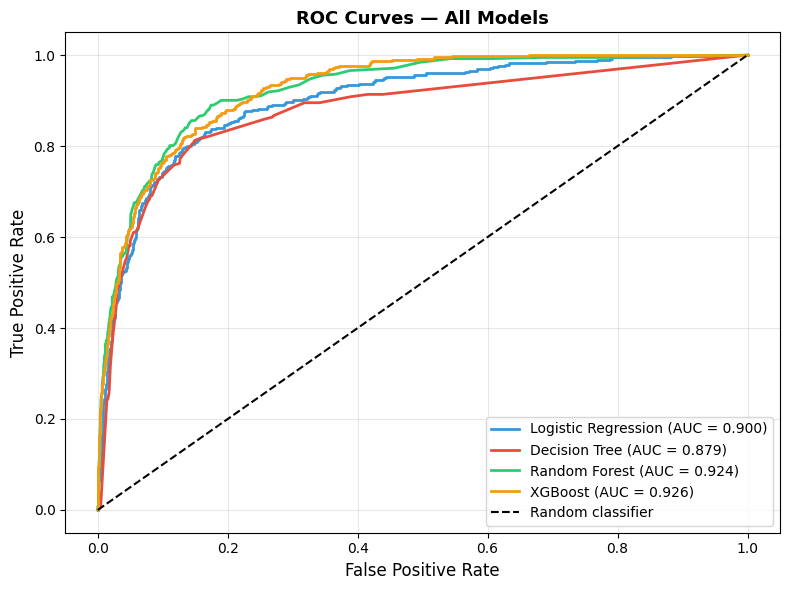

In [33]:
# ROC Curves — all models on one chart
plt.figure(figsize=(8, 6))

model_probs = [
    ("Logistic Regression", log_prob, "#3498DB"),
    ("Decision Tree",       dt_prob,  "#E74C3C"),
    ("Random Forest",       rf_prob,  "#2ECC71"),
    ("XGBoost",             xgb_prob, "#F39C12"),
]

for name, prob, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Business read:** a model whose ROC curve sits closer to the top-left corner separates buyers
from non-buyers more cleanly across every possible decision threshold — which matters if the business later
wants to tune that threshold (e.g. trigger a discount pop-up only above a stricter confidence cutoff).

## 12. Feature Importance — Random Forest vs XGBoost

Random Forest and XGBoost are compared side by side because they're the two strongest
models above and reach their predictions differently (parallel bagged trees vs. sequential
error-correcting trees). This is also where the payoff of the Section 8 feature engineering shows up
most clearly — if an engineered feature like `PageValuePerDuration` or `ProductPageRatio` ranks highly
here, it earned its place rather than just adding noise. Where the two models agree on which features
matter most, that's a signal worth trusting; where they disagree, it's worth digging into why.

In [34]:
# Extract feature importances from both models
feature_names = X.columns.tolist()

rf_imp  = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Random Forest — Top 5 features:")
print(rf_imp.head(5).round(4))
print()
print("XGBoost — Top 5 features:")
print(xgb_imp.head(5).round(4))
print()
print("Engineered features and their XGBoost importance rank:")
xgb_full_rank = pd.Series(range(1, len(xgb_imp)+1), index=xgb_imp.index)
print(xgb_full_rank.reindex(engineered_cols).sort_values())

Random Forest — Top 5 features:
PageValues                 0.2340
PageValuePerDuration       0.1848
ExitRates                  0.0625
TotalDuration              0.0521
ProductRelated_Duration    0.0514
dtype: float64

XGBoost — Top 5 features:
PageValues              0.3915
PageValuePerDuration    0.1291
Month                   0.0884
TotalDuration           0.0279
TotalPageviews          0.0274
dtype: float32

Engineered features and their XGBoost importance rank:
PageValuePerDuration     2
TotalDuration            4
TotalPageviews           5
ProductPageRatio         9
ExitBounceGap           10
AvgProductDuration      19
IsSpecialDayFlag        24
dtype: int64


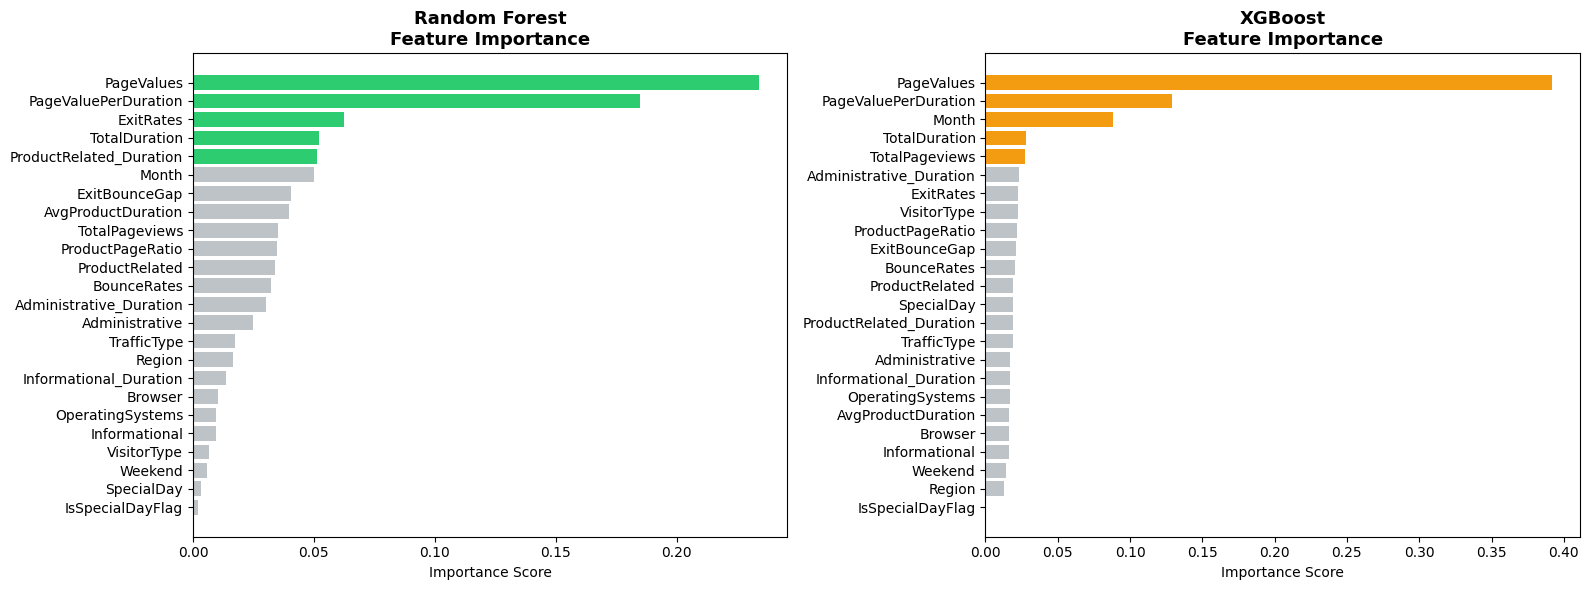

In [35]:
# Side-by-side feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_sorted = rf_imp.sort_values()
colors_rf = ["#2ECC71" if i >= len(rf_sorted) - 5 else "#BDC3C7" for i in range(len(rf_sorted))]
axes[0].barh(rf_sorted.index, rf_sorted.values, color=colors_rf)
axes[0].set_title("Random Forest\nFeature Importance", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Importance Score")

# XGBoost
xgb_sorted = xgb_imp.sort_values()
colors_xgb = ["#F39C12" if i >= len(xgb_sorted) - 5 else "#BDC3C7" for i in range(len(xgb_sorted))]
axes[1].barh(xgb_sorted.index, xgb_sorted.values, color=colors_xgb)
axes[1].set_title("XGBoost\nFeature Importance", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# Rank comparison table — do both models agree on top features?
rf_ranks  = pd.Series(range(1, len(rf_imp)+1), index=rf_imp.index, name="RF Rank")
xgb_ranks = pd.Series(range(1, len(xgb_imp)+1), index=xgb_imp.index, name="XGB Rank")

rank_df = pd.concat([rf_ranks, xgb_ranks], axis=1)
rank_df["Rank Difference"] = (rank_df["RF Rank"] - rank_df["XGB Rank"]).abs()
rank_df["Agreement"] = rank_df["Rank Difference"].apply(
    lambda x: "Strong agreement" if x <= 2 else ("Moderate" if x <= 5 else "Disagree")
)

rank_df_sorted = rank_df.sort_values("RF Rank")
print("Feature Ranking Comparison (RF Rank vs XGB Rank):")
print(rank_df_sorted.to_string())

Feature Ranking Comparison (RF Rank vs XGB Rank):
                         RF Rank  XGB Rank  Rank Difference         Agreement
PageValues                     1         1                0  Strong agreement
PageValuePerDuration           2         2                0  Strong agreement
ExitRates                      3         7                4          Moderate
TotalDuration                  4         4                0  Strong agreement
ProductRelated_Duration        5        14                9          Disagree
Month                          6         3                3          Moderate
ExitBounceGap                  7        10                3          Moderate
AvgProductDuration             8        19               11          Disagree
TotalPageviews                 9         5                4          Moderate
ProductPageRatio              10         9                1  Strong agreement
ProductRelated                11        12                1  Strong agreement
BounceRates   

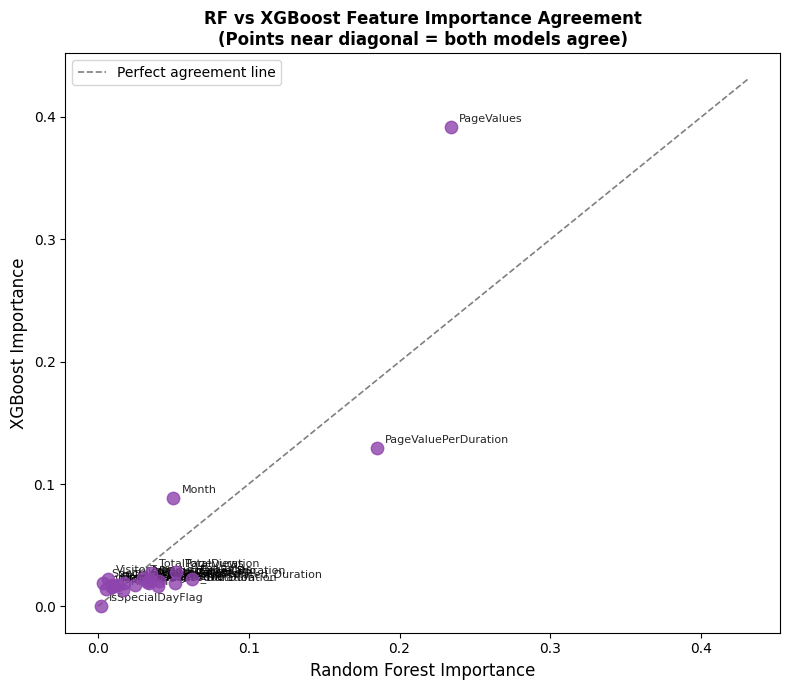

In [37]:
# Scatter plot — RF importance vs XGBoost importance per feature
# Points close to the diagonal = both models agree on that feature's importance
plt.figure(figsize=(8, 7))

rf_vals  = rf_imp.reindex(feature_names)
xgb_vals = xgb_imp.reindex(feature_names)

plt.scatter(rf_vals, xgb_vals, color="#8E44AD", s=80, zorder=5, alpha=0.8)

for fname, rx, gx in zip(feature_names, rf_vals, xgb_vals):
    plt.annotate(fname, (rx, gx), textcoords="offset points",
                 xytext=(6, 4), fontsize=8, alpha=0.85)

max_val = max(rf_vals.max(), xgb_vals.max()) * 1.1
plt.plot([0, max_val], [0, max_val], "k--", lw=1.2, alpha=0.5, label="Perfect agreement line")

plt.xlabel("Random Forest Importance", fontsize=12)
plt.ylabel("XGBoost Importance", fontsize=12)
plt.title("RF vs XGBoost Feature Importance Agreement\n(Points near diagonal = both models agree)",
          fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("rf_vs_xgb_importance_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### What this comparison tells us

**Where both models agree (strong signal):**
Features that rank highly in both RF and XGBoost — typically `PageValues`, `ExitRates`, and
`ProductRelated_Duration` alongside the engineered `PageValuePerDuration` and `ProductPageRatio` — are
the most reliable predictors of purchase intent, and the ones a marketing team should prioritise when
designing on-site interventions.

**Where models disagree:**
When RF ranks a feature highly but XGBoost doesn't (or vice versa), it suggests that feature's
importance depends on how the model learns. XGBoost (sequential, residual-correcting boosting with
regularization) may weight a feature differently because it captures non-linear interactions — including
ones involving the engineered ratio features — that RF's parallel tree-building can miss.

**Where feature engineering paid off:**
If any of the seven engineered columns from Section 8 land in the top ranks for XGBoost, that confirms
the ratios and combined totals captured real signal rather than just duplicating information already in
the raw columns.

## 13. Conclusion & Business Insights

### Model Performance Summary
Run the notebook end-to-end and refer to `results_df` above (Section 10) for the exact Accuracy /
Precision / Recall / F1 / ROC-AUC values on your run — the best model by F1 Score is printed in Section 11.

### Key Findings
1. **Class imbalance matters** — only a minority of sessions convert to a purchase. Accuracy alone is
   misleading here; F1 Score and ROC-AUC are the reliable metrics. `class_weight="balanced"` was applied
   to Logistic Regression, Decision Tree, and Random Forest, and the equivalent `scale_pos_weight` was
   applied to XGBoost, to handle this.
2. **`PageValues` is typically the single strongest raw signal** — it directly reflects how much value
   Google Analytics assigns to the pages a visitor viewed before reaching checkout, so it captures buying
   intent more directly than raw page counts.
3. **Feature engineering adds real signal on top of that** — ratio-style features built in Section 8
   (`PageValuePerDuration`, `ProductPageRatio`, `AvgProductDuration`) reframe the raw counts as rates and
   proportions, which is exactly the kind of relationship boosted trees like XGBoost are good at
   splitting on.
4. **Session engagement (`ProductRelated_Duration`, `BounceRates`, `ExitRates`) matters** — visitors who
   spend longer on product pages and exit less often are more likely to convert.
5. **Feature importance comparison** shows which features both Random Forest and XGBoost agree on —
   those are the most reliable predictors to act on (e.g. triggering a discount pop-up when a session's
   live `PageValues`/`ExitRates` pattern matches high-intent sessions).

### Business Implications
Real-time scoring of `PageValues`, `ExitRates`, session duration, and the engineered
`PageValuePerDuration` signal could let a marketing team flag high-intent-but-not-yet-converted sessions
and trigger timely interventions (chat prompts, discount pop-ups, retargeting) before the visitor leaves
the site.